# Task 3- CNN architecture

Neural networks require us to flatten the image into a 1D tensor, but while doing so we loose spatial context

To avoid that we make use of many layers such as Convolutional, Pooling,Dropout etc


THE Dataset
The total number of images in the dataset is 60000
Single image shape: torch.Size([1, 28, 28])
Associated target label: 2


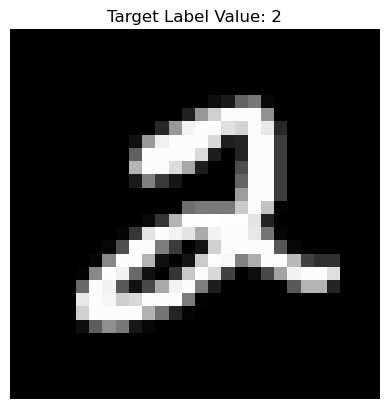

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])


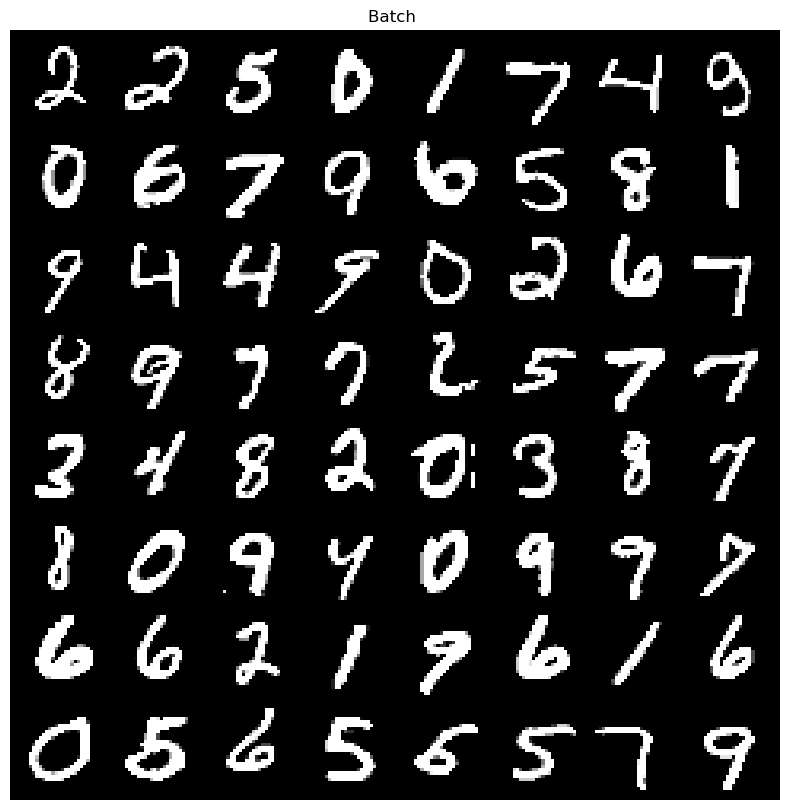

In [22]:
#copying task 2 code to move ahead
#Copying all the code from task 1 to move forward

import torch
import torchvision  #lib for computer vision in pytorch ecosystem
from torchvision.transforms import Compose, ToTensor, Normalize
import matplotlib.pyplot as plt 
#To transform the raw images (in png format) to tensors format we make us of the following:

transformy =Compose([
    ToTensor(), # it also scales the pixel values from [0,255] to [0,1] by dividing each value by 255
    
    #We normalize the pixel values further to center the data around 0 to help with the math.
    # The mean for the MNSIT dataset is 0.1307 and std dev is 0.3081 so we nromalize around these two using ((x-0.1307)/0.3081)
    Normalize((0.1307,),(0.3081,))
])

#downloading the dataset - both the training one and test one and applying transform on each image
train_dataset=torchvision.datasets.MNIST(
    root='./data',
    train = True,
    download=True,
    transform=transformy
)

test_dataset=torchvision.datasets.MNIST(
    root='./data',
    train= False,
    download=True,
    transform=transformy
)
print("THE Dataset")
print(f"The total number of images in the dataset is {len(train_dataset)}")
#The Mnsit dataset is in form of tuple pairs of the (image,itslabel integer)

single_image, single_label= train_dataset[5] #by changing the index we can access different images and look at their shapes 
print(f"Single image shape: {single_image.shape}")
print(f"Associated target label: {single_label}")
#Using matplotlib to render the images 
plt.imshow(single_image.squeeze(), cmap='gray') #squeeze changes the shape from [1,28,28] to [28,28] so that matplotlib can understand
plt.title(f"Target Label Value: {single_label}")
plt.axis('off')#disables the axes
plt.show()# final output
# A Dataloader is something that wraps an iterable about the dataset and helps in easier access to the data items.
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=64, shuffle=False)
#Batch size=64 meaning 64 similar images are grouped together into a batch , shuffling the training dataset is important so that it doesnt memorize the sequence.
# To iterate through the dataloader we convert it into a python iterator using iter(), next() grabs each batch 
image_batch, label_batch = next(iter(train_loader))
# features of the batch
print(f"Batch of images shape: {image_batch.shape}") #[batch size, channel, height, width]
print(f"Batch of labels shape: {label_batch.shape}")
#rendering a batch by making a grid in pytorch and then converting it to matplotlib's layout using .permute()
grid_tensor = torchvision.utils.make_grid(image_batch, nrow=8, padding=2)
grid_np = grid_tensor.permute(1, 2, 0).numpy()# by pytorch [C-0,H-1,W-2] --> by matplotlob [H,W,C] so(1,2,0)
plt.figure(figsize=(10, 10))
plt.imshow(grid_np)
plt.title("Batch ")
plt.axis('off')
plt.show()

In [23]:
import torch 
import torch.nn as nn       # nn.Module is the base class for every neural network and is used to manage, train and test.
import torch.nn.functional as F


In [24]:
class MNIST_CNN(nn.Module): # a class inheriting nn.Module class
        def __init__(self):
                super(MNIST_CNN, self).__init__() # super() is used to directly use the parent class

                # first convolutional block , 1 input channel (greyscale)- 32 output channels(32 filters)
                self.conv1=nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)

                # max pooling layer- shrinks the image size and also the number of calculations, (2x2) pooling layer gives the max value in a (2x2) neighbourhood
                self.pool= nn.MaxPool2d(kernel_size=2,stride=2) #reduces height and width by half

                #second convolution block, 32 input channels(feature maps from conv1), 64 output channels(more filters)
                self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

                #dropout layer- turns off a given percenrage of neurons. Done to counter overfitting.
                self.dropout = nn.Dropout(p=0.25) #switches off 25% of neurons

                #fully connected layers - to finally flatten the grid to 1D vector.
                #start- 28x28 -> conv1->28x28->pool->14x14->conv2->14x14
                #total flattened features :64channels*14h*14w
                self.fc1 = nn.Linear(in_features=64 * 14 * 14, out_features=128)

                #final output layer- 128 hidden features -> 10 output(digits 0-9)
                self.fc2 = nn.Linear(in_features=128, out_features=10)

        def forward(self, x):
                        # Pass through Conv1, activate with ReLU, and apply downsampling MaxPool
                        x = self.pool(F.relu(self.conv1(x)))  # [64, 1, 28, 28] -> [64, 32, 14, 14]
        
                        # Pass through Conv2 and activate with ReLU only (No pooling here)
                        x = F.relu(self.conv2(x))             # [64, 32, 14, 14] -> [64, 64, 14, 14]
        
                        # Flatten the multidimensional grid into a 1D vector per image batch sample
                        # -1 automatically retains our batch dimension size (64)
                        x = x.view(-1, 64 * 14 * 14)          # [64, 64, 14, 14] -> [64, 12544]
        
                        # Apply dropout to keep the network from memorizing pixel placements
                        x = self.dropout(x)
        
                        # Run through the dense hidden layer with ReLU activation
                        x = F.relu(self.fc1(x))               # [64, 12544] -> [64, 128]
        
                        # Final output layer to fetch raw class scores
                        x = self.fc2(x)                       # [64, 128] -> [64, 10]
        
                        return x


In [25]:
# 1. A physical instance of your neural network chassis
model = MNIST_CNN()
print("🎉 Model architecture successfully built without errors!")

# 2. Extracting a training batch
test_images, test_labels = next(iter(train_loader))

# 3. A mock test-drive pass through your forward function
output_logits = model(test_images)

print("\nStructural Diagnostics")
print(f"Input image batch tensor shape:  {test_images.shape}  -> [Batch, Channels, Height, Width]")
print(f"Output predicted logit tensor shape: {output_logits.shape}   -> [Batch, Target Classes]")

# Calculate total network weights/biases
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model trainable weights/parameters: {total_params:,}")

🎉 Model architecture successfully built without errors!



Structural Diagnostics
Input image batch tensor shape:  torch.Size([64, 1, 28, 28])  -> [Batch, Channels, Height, Width]
Output predicted logit tensor shape: torch.Size([64, 10])   -> [Batch, Target Classes]
Total model trainable weights/parameters: 1,625,866
